In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback

# Add the current directory to path to ensure we can import the environment module
sys.path.append(os.getcwd())

# Import the environment registration
import gymnasium_env_2
print("Environment registered.")

2026-02-03 21:44:32.214371: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 21:44:32.268147: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 21:44:33.717419: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Environment registered.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Configuration
ENV_ID = "gymnasium_env_2/LDPC-TanhResidual-v0"
TRAIN_SNR = 4.0  # Train at a challenging SNR
DEBUG_STEPS = 5000
FULL_STEPS = 100000

def train_agent(total_timesteps, model_name="dqn_ldpc"):
    env = gym.make(ENV_ID, snr_db=TRAIN_SNR)
    
    model = DQN(
        "MlpPolicy", 
        env, 
        learning_rate=1e-4,
        buffer_size=10000,
        learning_starts=1000,
        batch_size=32,
        exploration_fraction=0.1,
        exploration_final_eps=0.02,
        verbose=1,
        tensorboard_log="./tensorboard_logs/"
    )
    
    print(f"Starting training for {total_timesteps} steps...")
    model.learn(total_timesteps=total_timesteps)
    print("Training complete.")
    
    model.save(model_name)
    return model

# Debug Run
print("Running short debug training...")
debug_model = train_agent(DEBUG_STEPS, model_name="dqn_ldpc_debug")

Running short debug training...


/root/.pyenv/versions/myenv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/root/.pyenv/versions/myenv/lib/python3.12/site-packages/pkg_resources/__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training for 5000 steps...
Logging to ./tensorboard_logs/DQN_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.75     |
|    ep_rew_mean      | 20.7     |
|    exploration_rate | 0.963    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 647      |
|    time_elapsed     | 0        |
|    total_timesteps  | 19       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.12     |
|    ep_rew_mean      | 37       |
|    exploration_rate | 0.888    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 802      |
|    time_elapsed     | 0        |
|    total_timesteps  | 57       |
----------------------------------
----------------------------------
| rollout/            |     

In [3]:
# Full Run
print(f"Running full training for {FULL_STEPS} steps...")
final_model = train_agent(FULL_STEPS, model_name="dqn_ldpc_100k")

Running full training for 100000 steps...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training for 100000 steps...
Logging to ./tensorboard_logs/DQN_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 6.75     |
|    ep_rew_mean      | 31.5     |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1047     |
|    time_elapsed     | 0        |
|    total_timesteps  | 27       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 7.25     |
|    ep_rew_mean      | 31.4     |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1156     |
|    time_elapsed     | 0        |
|    total_timesteps  | 58       |
----------------------------------
-------------------


Starting evaluation...
Evaluating at SNR 0 dB...
SNR 0 dB: BER = 0.075453
Evaluating at SNR 1 dB...
SNR 1 dB: BER = 0.045391
Evaluating at SNR 2 dB...
SNR 2 dB: BER = 0.021955
Evaluating at SNR 3 dB...
SNR 3 dB: BER = 0.007140
Evaluating at SNR 4 dB...
SNR 4 dB: BER = 0.001564
Evaluating at SNR 5 dB...
SNR 5 dB: BER = 0.000514
Evaluating at SNR 6 dB...
SNR 6 dB: BER = 0.000103


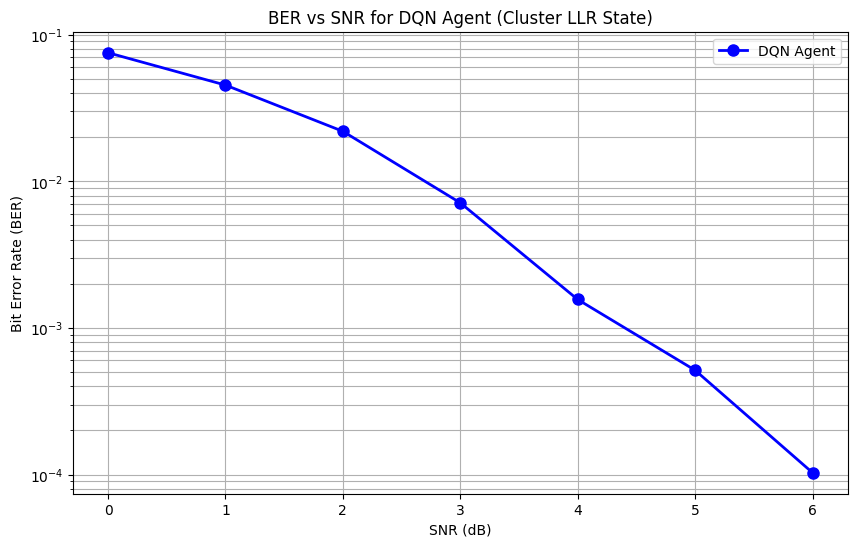

In [5]:
def evaluate_ber(model, snr_points, num_episodes=10000):
    ber_values = []
    
    for snr in snr_points:
        env = gym.make(ENV_ID, snr_db=snr)
        
        total_bit_errors = 0
        total_bits = 0
        
        print(f"Evaluating at SNR {snr} dB...")
        
        for _ in range(num_episodes):
            obs, _ = env.reset()
            done = False
            truncated = False
            
            while not (done or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, truncated, info = env.step(action)
            
            # Calculate bit errors at the end of the episode
            # Access underlying environment variables
            inner_env = env.unwrapped
            decoded_bits = (inner_env.current_llr < 0).astype(int)[:inner_env.n]
            errors = np.count_nonzero(decoded_bits != inner_env.message)
            
            total_bit_errors += errors
            total_bits += inner_env.n
            
        ber = total_bit_errors / total_bits
        ber_values.append(ber)
        print(f"SNR {snr} dB: BER = {ber:.6f}")
        
    return ber_values

# Define SNR range
snr_range = [0, 1, 2, 3, 4, 5, 6]

# Evaluate
print("\nStarting evaluation...")
ber_curve = evaluate_ber(final_model, snr_range, num_episodes=100) # 100 episodes for speed, increase for precision

# Plot
plt.figure(figsize=(10, 6))
plt.semilogy(snr_range, ber_curve, 'bo-', linewidth=2, markersize=8, label='DQN Agent')
plt.grid(True, which="both", ls="-")
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('BER vs SNR for DQN Agent (Cluster LLR State)')
plt.legend()
plt.savefig('ber_vs_snr_dqn.png')
plt.show()